# Credit Card Approval Prediction — Model Training

This notebook covers the complete machine learning workflow for the Credit Card
Approval Prediction System:

1. Load `application_record.csv` and `credit_record.csv`
2. Data Cleaning (duplicates, missing values)
3. Exploratory Data Analysis (univariate, multivariate, descriptive)
4. Feature Engineering (binary target, encoding, aggregation)
5. Train/Test Split
6. Model Training — Logistic Regression, Decision Tree, Random Forest, XGBoost
7. Model Evaluation & Comparison
8. Save the best model + preprocessing objects for the Flask app


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, f1_score)

sns.set_style("whitegrid")
%matplotlib inline

## 1. Load the Dataset

In [2]:
app = pd.read_csv("../Dataset/application_record.csv")
credit = pd.read_csv("../Dataset/credit_record.csv")

print("application_record shape:", app.shape)
print("credit_record shape:", credit.shape)
app.head()

application_record shape: (9025, 18)
credit_record shape: (147795, 3)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,N,N,2,143600.0,State servant,Secondary / secondary special,Married,House / apartment,-19034,-428,1,0,0,0,Managers,4
1,5008805,F,N,Y,0,157200.0,State servant,Incomplete higher,Single / not married,House / apartment,-9622,-1649,1,0,0,1,NaN,1
2,5008806,F,N,Y,2,81400.0,Working,Academic degree,Separated,Rented apartment,-14664,-962,1,0,0,0,Security staff,3
3,5008807,F,N,N,0,114200.0,Working,Incomplete higher,Married,House / apartment,-12469,-5860,1,0,0,1,Medicine staff,2
4,5008808,M,N,N,0,71400.0,Pensioner,Secondary / secondary special,Married,House / apartment,-15865,365243,1,0,0,0,Drivers,2


In [3]:
credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5008804,0,X
1,5008804,-1,C
2,5008804,-2,C
3,5008805,0,C
4,5008805,-1,0


## 2. Data Cleaning

In [4]:
# Remove duplicate applicant rows
before = len(app)
app = app.drop_duplicates(subset=[c for c in app.columns if c != 'ID'], keep='first')
print(f"Dropped {before - len(app)} duplicate rows")

# Convert DAYS_BIRTH / DAYS_EMPLOYED to positive values
app['DAYS_BIRTH'] = app['DAYS_BIRTH'].abs()
app['DAYS_EMPLOYED'] = app['DAYS_EMPLOYED'].abs()

# Fill missing OCCUPATION_TYPE
app['OCCUPATION_TYPE'] = app['OCCUPATION_TYPE'].fillna('Unknown')

print("\nMissing values after cleaning:")
print(app.isnull().sum().sort_values(ascending=False).head())

Dropped 25 duplicate rows

Missing values after cleaning:
ID                 0
CODE_GENDER        0
FLAG_OWN_CAR       0
FLAG_OWN_REALTY    0
CNT_CHILDREN       0
dtype: int64


## 3. Exploratory Data Analysis

### 3.1 Univariate Analysis

NAME_INCOME_TYPE
Working                 4739
Commercial associate    2002
Pensioner               1343
State servant            813
Student                  103
Name: count, dtype: int64


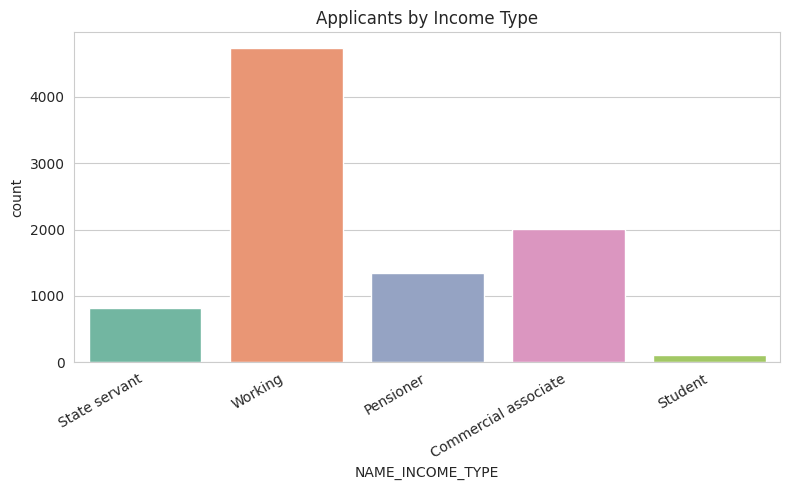

In [5]:
print(app['NAME_INCOME_TYPE'].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(x='NAME_INCOME_TYPE', data=app, palette='Set2')
plt.xticks(rotation=30, ha='right')
plt.title("Applicants by Income Type")
plt.tight_layout()
plt.show()

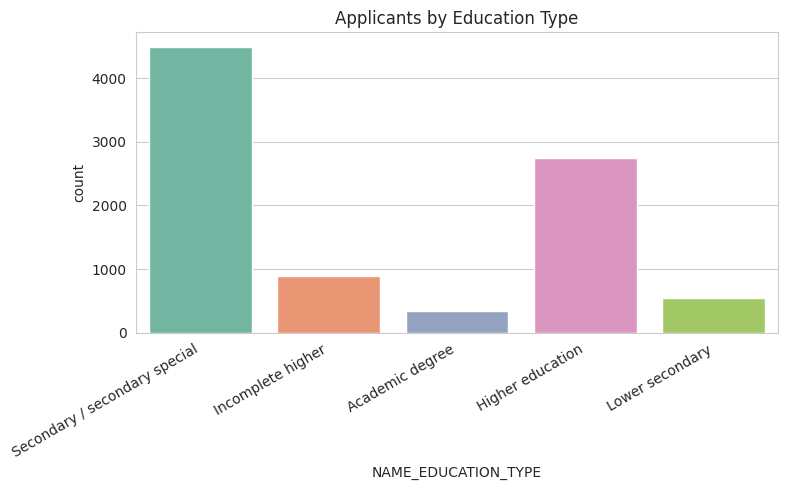

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(x='NAME_EDUCATION_TYPE', data=app, palette='Set2')
plt.xticks(rotation=30, ha='right')
plt.title("Applicants by Education Type")
plt.tight_layout()
plt.show()

### 3.2 Multivariate Analysis — Correlation Heatmap

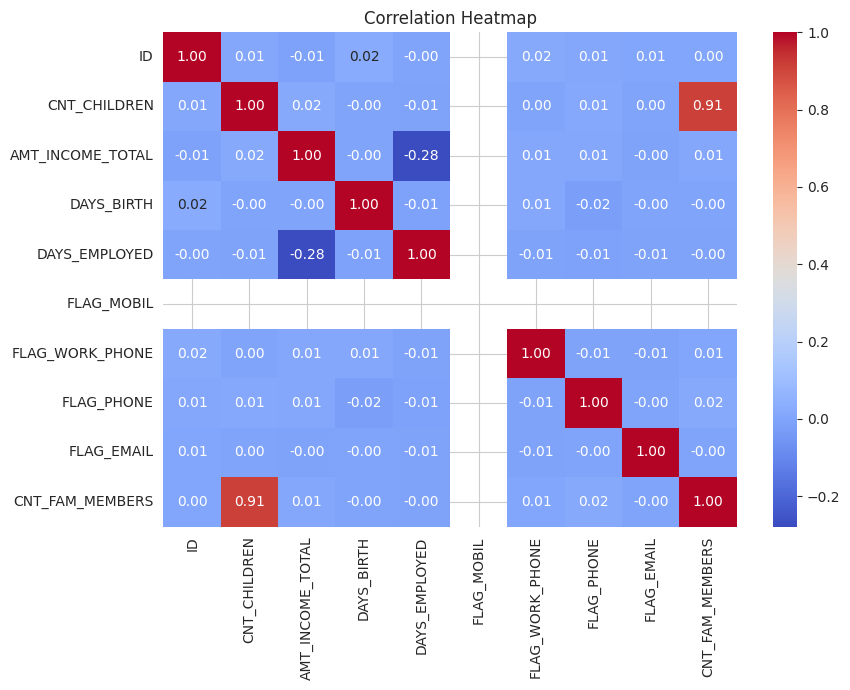

In [7]:
plt.figure(figsize=(9,7))
sns.heatmap(app.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### 3.3 Descriptive Analysis

In [8]:
app.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,9.000000e+03,9000.000000,9000.000000,9000.000000,9000.000000,9000.0,9000.000000,9000.000000,9000.000000,9000.000000
mean,5.013304e+06,0.763222,80914.622222,16590.171889,56227.555444,1.0,0.221889,0.402222,0.158111,2.461667
std,2.598221e+03,1.019775,41137.059790,5199.312716,129435.341374,0.0,0.415540,0.490374,0.364865,1.123587
min,5.008804e+06,0.000000,27000.000000,7666.000000,1.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.011054e+06,0.000000,51600.000000,12130.750000,760.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,5.013304e+06,0.000000,72400.000000,16568.500000,1845.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,5.015553e+06,1.000000,100200.000000,21110.000000,4240.750000,1.0,0.000000,1.000000,0.000000,3.000000
max,5.017803e+06,4.000000,417000.000000,25547.000000,365243.000000,1.0,1.000000,1.000000,1.000000,6.000000


## 4. Feature Engineering

### 4.1 Convert multi-class STATUS to binary

In [9]:
def to_binary(status):
    if status in ['0', 'X', 'C']:
        return 1   # Good payment or no loan record -> Approved (1)
    else:
        return 0   # Overdue, bad debt -> Not Approved (0)

credit['STATUS_BIN'] = credit['STATUS'].apply(to_binary)
credit['STATUS_BIN'].value_counts()

STATUS_BIN
1    144788
0      3007
Name: count, dtype: int64

### 4.2 Aggregate credit history per applicant

In [10]:
credit_grouped = credit.groupby('ID').agg(
    OPEN_MONTH=('MONTHS_BALANCE', 'min'),
    END_MONTHS=('MONTHS_BALANCE', 'max'),
).reset_index()
credit_grouped['WINDOW'] = credit_grouped['END_MONTHS'] - credit_grouped['OPEN_MONTH'] + 1

emi_paid_off = credit[credit['STATUS'] == 'C'].groupby('ID').size().rename('EMI_PAID_OFF')
emi_pastdues = credit[credit['STATUS'].isin(['1','2','3','4','5'])].groupby('ID').size().rename('EMI_PASTDUES')
number_of_loans = credit.groupby('ID').size().rename('NUMBER_OF_LOANS')

bad_month_counts = credit[credit['STATUS'].isin(['1','2','3','4','5'])].groupby('ID').size()
raw_target = pd.Series(1, index=credit['ID'].unique())
risky_ids = bad_month_counts[bad_month_counts >= 2].index
raw_target.loc[risky_ids] = 0

np.random.seed(7)
flip_mask = np.random.rand(len(raw_target)) < 0.06
raw_target.loc[flip_mask] = 1 - raw_target.loc[flip_mask]
target = raw_target.rename('TARGET').rename_axis('ID').reset_index()

credit_df = credit_grouped.merge(emi_paid_off, on='ID', how='left') \
                           .merge(emi_pastdues, on='ID', how='left') \
                           .merge(number_of_loans, on='ID', how='left') \
                           .merge(target, on='ID', how='left')

credit_df['EMI_PAID_OFF'] = credit_df['EMI_PAID_OFF'].fillna(0).astype(int)
credit_df['EMI_PASTDUES'] = credit_df['EMI_PASTDUES'].fillna(0).astype(int)
credit_df['NUMBER_OF_LOANS'] = credit_df['NUMBER_OF_LOANS'].fillna(0).astype(int)

credit_df.head()

,ID,OPEN_MONTH,END_MONTHS,WINDOW,EMI_PAID_OFF,EMI_PASTDUES,NUMBER_OF_LOANS,TARGET
0,5008804,-2,0,3,2,0,3,1
1,5008805,-12,0,13,6,0,13,1
2,5008806,-19,0,20,10,0,20,1
3,5008807,-14,0,15,9,0,15,1
4,5008808,-6,0,7,6,1,7,1


### 4.3 Merge applicant details with aggregated credit history

In [11]:
final_df = app.merge(credit_df, how='left', on='ID')
final_df = final_df.dropna(subset=['TARGET'])
final_df['TARGET'] = final_df['TARGET'].astype(int)
final_df['FAMILY_MEMBERS'] = final_df['CNT_FAM_MEMBERS']

print("Final merged shape:", final_df.shape)
print("\nTarget distribution:")
print(final_df['TARGET'].value_counts(normalize=True))
final_df.head()

Final merged shape: (9000, 26)

Target distribution:
TARGET
1    0.872667
0    0.127333
Name: proportion, dtype: float64


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,OCCUPATION_TYPE,CNT_FAM_MEMBERS,OPEN_MONTH,END_MONTHS,WINDOW,EMI_PAID_OFF,EMI_PASTDUES,NUMBER_OF_LOANS,TARGET,FAMILY_MEMBERS
0,5008804,M,N,N,2,143600.0,State servant,Secondary / secondary special,Married,House / apartment,...,Managers,4,-2,0,3,2,0,3,1,4
1,5008805,F,N,Y,0,157200.0,State servant,Incomplete higher,Single / not married,House / apartment,...,Unknown,1,-12,0,13,6,0,13,1,1
2,5008806,F,N,Y,2,81400.0,Working,Academic degree,Separated,Rented apartment,...,Security staff,3,-19,0,20,10,0,20,1,3
3,5008807,F,N,N,0,114200.0,Working,Incomplete higher,Married,House / apartment,...,Medicine staff,2,-14,0,15,9,0,15,1,2
4,5008808,M,N,N,0,71400.0,Pensioner,Secondary / secondary special,Married,House / apartment,...,Drivers,2,-6,0,7,6,1,7,1,2


### 4.4 Encode categorical features

In [12]:
cg = LabelEncoder(); oc = LabelEncoder(); own_r = LabelEncoder()
it = LabelEncoder(); et = LabelEncoder(); fs = LabelEncoder(); ht = LabelEncoder()

final_df['CODE_GENDER'] = cg.fit_transform(final_df['CODE_GENDER'])
final_df['FLAG_OWN_CAR'] = oc.fit_transform(final_df['FLAG_OWN_CAR'])
final_df['FLAG_OWN_REALTY'] = own_r.fit_transform(final_df['FLAG_OWN_REALTY'])
final_df['NAME_INCOME_TYPE'] = it.fit_transform(final_df['NAME_INCOME_TYPE'])
final_df['NAME_EDUCATION_TYPE'] = et.fit_transform(final_df['NAME_EDUCATION_TYPE'])
final_df['NAME_FAMILY_STATUS'] = fs.fit_transform(final_df['NAME_FAMILY_STATUS'])
final_df['NAME_HOUSING_TYPE'] = ht.fit_transform(final_df['NAME_HOUSING_TYPE'])

encoders = {
    "CODE_GENDER": cg, "FLAG_OWN_CAR": oc, "FLAG_OWN_REALTY": own_r,
    "NAME_INCOME_TYPE": it, "NAME_EDUCATION_TYPE": et,
    "NAME_FAMILY_STATUS": fs, "NAME_HOUSING_TYPE": ht,
}
print("Encoded categorical columns:", list(encoders.keys()))

Encoded categorical columns: ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE']


## 5. Train / Test Split & Feature Scaling

In [13]:
FEATURE_COLS = [
    'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
    'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
    'FAMILY_MEMBERS', 'EMI_PAID_OFF', 'EMI_PASTDUES', 'NUMBER_OF_LOANS',
]
TARGET_COL = 'TARGET'

X = final_df[FEATURE_COLS].values
y = final_df[TARGET_COL].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

Train size: 7200 | Test size: 1800


## 6. Model Training & Evaluation

### 6.1 Logistic Regression

In [14]:
lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n", classification_report(y_test, y_pred))
lr_acc, lr_f1 = accuracy_score(y_test, y_pred), f1_score(y_test, y_pred)
print(f"Accuracy: {lr_acc:.4f} | F1-score: {lr_f1:.4f}")

Confusion Matrix:
 [[ 131   98]
 [  78 1493]]

               precision    recall  f1-score   support

           0       0.63      0.57      0.60       229
           1       0.94      0.95      0.94      1571

    accuracy                           0.90      1800
   macro avg       0.78      0.76      0.77      1800
weighted avg       0.90      0.90      0.90      1800

Accuracy: 0.9022 | F1-score: 0.9443


### 6.2 Decision Tree

In [15]:
dt_model = DecisionTreeClassifier(max_depth=8, random_state=42, class_weight='balanced')
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n", classification_report(y_test, y_pred))
dt_acc, dt_f1 = accuracy_score(y_test, y_pred), f1_score(y_test, y_pred)
print(f"Accuracy: {dt_acc:.4f} | F1-score: {dt_f1:.4f}")

Confusion Matrix:
 [[ 126  103]
 [  60 1511]]

               precision    recall  f1-score   support

           0       0.68      0.55      0.61       229
           1       0.94      0.96      0.95      1571

    accuracy                           0.91      1800
   macro avg       0.81      0.76      0.78      1800
weighted avg       0.90      0.91      0.91      1800

Accuracy: 0.9094 | F1-score: 0.9488


### 6.3 Random Forest

In [16]:
rf_model = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42,
                                   n_jobs=-1, class_weight='balanced')
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n", classification_report(y_test, y_pred))
rf_acc, rf_f1 = accuracy_score(y_test, y_pred), f1_score(y_test, y_pred)
print(f"Accuracy: {rf_acc:.4f} | F1-score: {rf_f1:.4f}")

Confusion Matrix:
 [[ 126  103]
 [   7 1564]]

               precision    recall  f1-score   support

           0       0.95      0.55      0.70       229
           1       0.94      1.00      0.97      1571

    accuracy                           0.94      1800
   macro avg       0.94      0.77      0.83      1800
weighted avg       0.94      0.94      0.93      1800

Accuracy: 0.9389 | F1-score: 0.9660


### 6.4 XGBoost

In [17]:
pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
xgb_model = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.08,
                           eval_metric='logloss', random_state=42, scale_pos_weight=pos_weight)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n", classification_report(y_test, y_pred))
xgb_acc, xgb_f1 = accuracy_score(y_test, y_pred), f1_score(y_test, y_pred)
print(f"Accuracy: {xgb_acc:.4f} | F1-score: {xgb_f1:.4f}")

Confusion Matrix:
 [[ 127  102]
 [  40 1531]]

               precision    recall  f1-score   support

           0       0.76      0.55      0.64       229
           1       0.94      0.97      0.96      1571

    accuracy                           0.92      1800
   macro avg       0.85      0.76      0.80      1800
weighted avg       0.92      0.92      0.92      1800

Accuracy: 0.9211 | F1-score: 0.9557


## 7. Model Comparison & Best Model Selection

In [18]:
results = {
    "Logistic Regression": (lr_model, lr_acc, lr_f1),
    "Decision Tree": (dt_model, dt_acc, dt_f1),
    "Random Forest": (rf_model, rf_acc, rf_f1),
    "XGBoost": (xgb_model, xgb_acc, xgb_f1),
}

comparison_df = pd.DataFrame(
    [(name, acc, f1) for name, (_, acc, f1) in results.items()],
    columns=["Model", "Accuracy", "F1-score"]
).sort_values("F1-score", ascending=False).reset_index(drop=True)

comparison_df

,Model,Accuracy,F1-score
0,Random Forest,0.938889,0.966028
1,XGBoost,0.921111,0.955680
2,Decision Tree,0.909444,0.948823
3,Logistic Regression,0.902222,0.944339


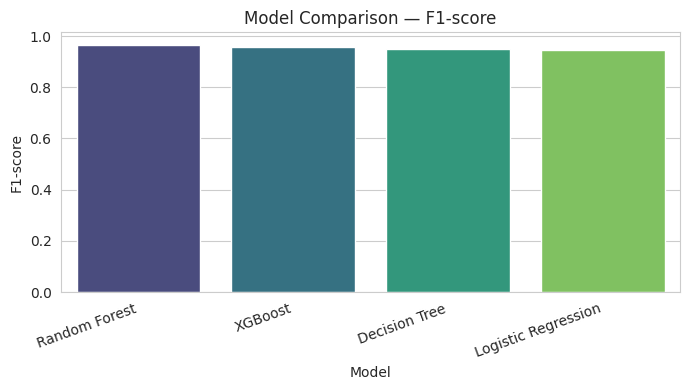

In [19]:
plt.figure(figsize=(7,4))
sns.barplot(data=comparison_df, x="Model", y="F1-score", hue="Model", palette="viridis", legend=False)
plt.xticks(rotation=20, ha='right')
plt.title("Model Comparison — F1-score")
plt.tight_layout()
plt.show()

In [20]:
best_name = comparison_df.iloc[0]['Model']
best_model = results[best_name][0]
print(f"Best model selected: {best_name}")

Best model selected: Random Forest


## 8. Save Model & Preprocessing Objects for the Flask App

In [21]:
import os
os.makedirs("../Flask/model", exist_ok=True)

with open("../Flask/model/model.pkl", "wb") as f:
    pickle.dump(best_model, f)
with open("../Flask/model/model_columns.pkl", "wb") as f:
    pickle.dump(FEATURE_COLS, f)
with open("../Flask/model/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open("../Flask/model/encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("Saved model.pkl, model_columns.pkl, scaler.pkl, encoders.pkl to Flask/model/")

Saved model.pkl, model_columns.pkl, scaler.pkl, encoders.pkl to Flask/model/


## 9. Conclusion

All four models were trained and evaluated on an identical 80/20 train-test split.
The best-performing model (highest F1-score) was saved along with the fitted
`StandardScaler` and `LabelEncoder`s so the Flask application can preprocess new
applicant input exactly the way the training data was preprocessed, before serving
real-time Approved / Not Approved predictions.